MSE: 2.5909525525662146e-16
NMSE: 3.681029043264554e-16
MSE_random: 0.010102116608094751
NMSE_random: 0.01435232173434085


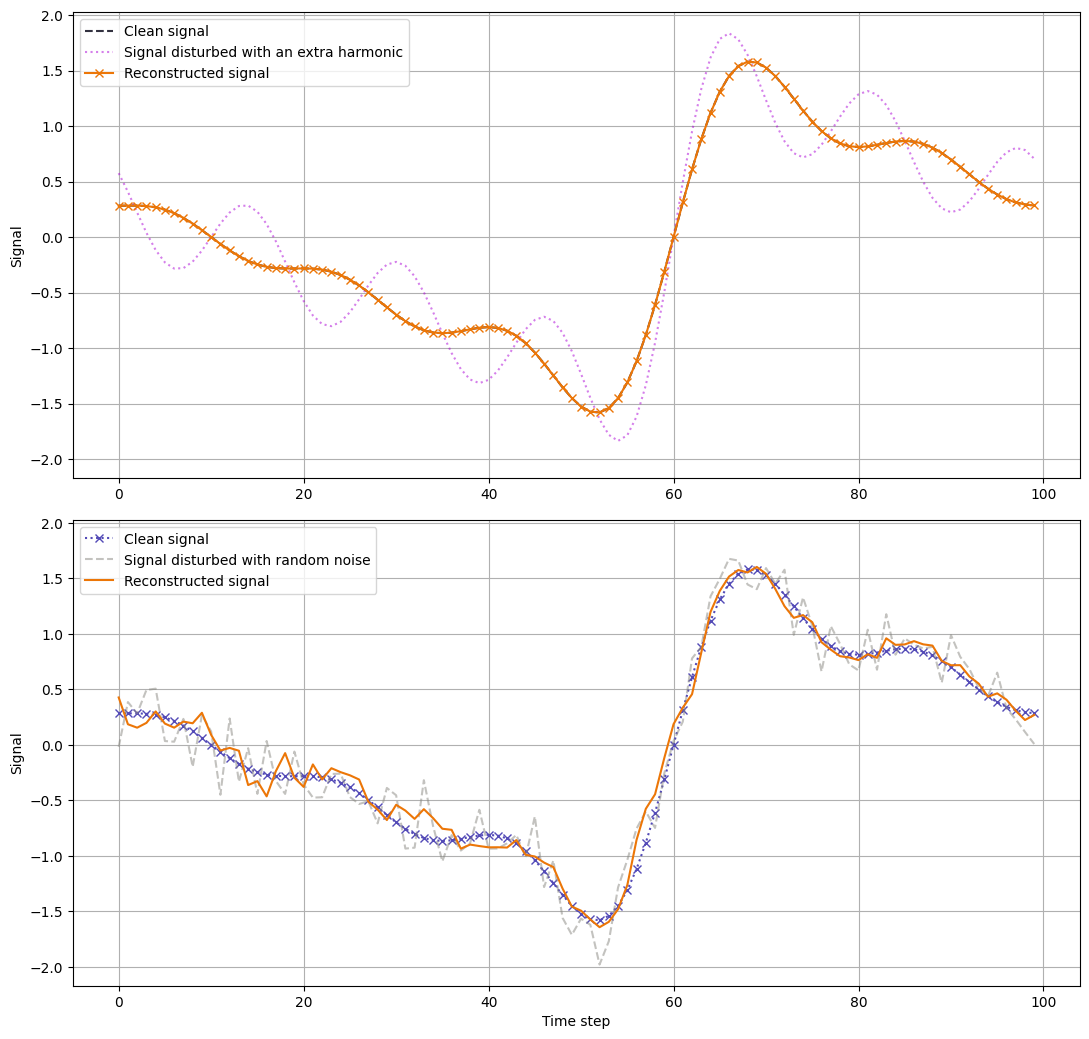

In [2]:

######################################
# The reconstruction tasks for the reservoir
# Task 1: Harmonic signal that is disturbed with an extra harmonic component. Reconstruct the clean signal
# Task 2: Harmonic signal that is disturbed with random noise. Reconstruct the clean signal
######################################


import numpy as np
import matplotlib.pyplot as plt
from reservoirpy.nodes import Reservoir, Ridge
import reservoirpy as rpy

# The seeds
rpy.set_seed(55)
rng=np.random.default_rng(55)

# Resevoir and the readout
# The reservoir parameters are the same as for the memory task


###
# Task 1
###
reservoir=Reservoir(500, lr=1.0, sr=0.99, input_scaling=0.5, activation="tanh")
readout_l=Ridge(ridge=1e-10)
 

# For the input
steps=np.arange(2000)
n= np.arange(1, 6)

# Clean signal
input_1=(np.sum((1/n)[:,None] * np.sin(2*np.pi*(n[:,None]*steps/100)), axis=0)).reshape(-1, 1)

# The disturbed signal. Has an additional harmonic component
noisy =input_1 + 0.5*np.sin(2*np.pi*6*steps/100).reshape(-1, 1)

# Run the disturbed signal through the reservoir
reservoir_states=reservoir.run(noisy)

# Washout
reservoir_states=reservoir_states[200:]
noisy_r= noisy[200:]
clean_r =input_1[200:]

# 80/20 train/test split
split= int(len(reservoir_states) * 0.8)
states_train= reservoir_states[:split]
states_test=reservoir_states[split:]
target_train = clean_r[:split]   # Learn the clean signal
target_test =clean_r[split:]
noisy_test= noisy_r[split:]

# train the readout with disturbed signal to produce the clean one
readout = readout_l.fit(states_train, target_train)

# The reconstruction
recon=readout.run(states_test)
mse=np.mean((target_test - recon)**2)
nmse=mse/np.var(target_test)
print("MSE:", mse)
print("NMSE:", nmse)


###
# Task 2, same procedure as abobe
###
reservoir2=Reservoir(500, lr=1.0, sr=0.99, input_scaling=0.5, activation="tanh")
readout_l2=Ridge(ridge=1e-10)

steps=np.arange(2000)
n= np.arange(1, 6)

input_2=(np.sum((1/n)[:,None] * np.sin(2*np.pi*(n[:,None]*steps/100)), axis=0)).reshape(-1, 1)

# Disturbed with random noise
noisy2 =input_2+ 0.2*rng.standard_normal(input_2.shape)
reservoir_states2=reservoir2.run(noisy2)

# Washout
reservoir_states2=reservoir_states2[200:]
noisy_r2= noisy2[200:]
clean_r2 =input_2[200:]

# 80/20 train/test split
split =int(len(reservoir_states2) * 0.8)
states_train2= reservoir_states2[:split]
states_test2=reservoir_states2[split:]
target_train2 = clean_r2[:split]
target_test2 =clean_r2[split:]
noisy_test2= noisy_r2[split:]

# train the readout
readout2 = readout_l2.fit(states_train2, target_train2)

# Reconstruct
recon2=readout2.run(states_test2)
mse2=np.mean((target_test2 - recon2)**2)
nmse2=mse2 / np.var(target_test2)
print("MSE_random:", mse2)
print("NMSE_random:", nmse2)



###
# The plot
###
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#2E2D3BF9", "#AB00D6", "#EC7607",
    "#534AB7", "#888780", "#EC7607"])

fig, axes= plt.subplots(2, 1, figsize=(11, 10.5), sharey=True)
axes[0].set_prop_cycle(plt.cycler(color=["#2E2D3BF9", "#AB00D6", "#EC7607"]))
axes[0].plot(target_test[:100], label="Clean signal", linestyle="--") 
axes[0].plot(noisy_test[:100], label="Signal disturbed with an extra harmonic", linestyle="dotted", alpha=0.5) 
axes[0].plot(recon[:100], label="Reconstructed signal", linestyle="solid", marker="x") 
axes[0].set_ylabel("Signal") 
axes[0].legend()
axes[0].grid(True)

axes[1].set_prop_cycle(plt.cycler(color=[
    "#534AB7", "#888780", "#EC7607"]))
axes[1].plot(target_test2[:100], label="Clean signal", linestyle="dotted", marker="x") 
axes[1].plot(noisy_test2[:100], label="Signal disturbed with random noise", linestyle="dashed", alpha=0.5) 
axes[1].plot(recon2[:100], label="Reconstructed signal", linestyle="solid") 
axes[1].set_ylabel("Signal") 
axes[1].set_xlabel("Time step") 
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()